In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from matplotlib import style
import seaborn as sns
from matplotlib import pyplot as plt

color=['0.3', '0.5', '0.7', '0.9']
linestyle=['-', '--', ':', '-.']
marker=['o', 'v', 'd', 'p']

pd.set_option('display.max_rows', 6)
from IPython.display import HTML
import networkx as nx

In [3]:
# =============================================================================
#  APPLY THEME  --  Beamer "Madrid" look. Re-run any time to refresh styling.
# =============================================================================
from pywrangling.jupyter_slides_functions import apply_beamer_theme
from pywrangling.graphing_functions import use_plotplainblind, set_top_ylabel
apply_beamer_theme(
    "madrid",
    skip_font_download=True,
    author="Robert Pettis",
    date="Fall 2026",
    show_slide_number=True,
    cell_tags=True,
    notebook_path="04b-Checkpoint-Quiz.ipynb",
)
import course_helpers as chh

<IPython.core.display.Javascript object>


✓ Cell tag CSS applied for 6 cell(s):
 cell_index  slide_id                                  tags
          0           slide_hide_prompt, slide_remove_input
          1           slide_hide_prompt, slide_remove_input
          2           slide_hide_prompt, slide_remove_input
          7 slide-2-0 slide_hide_prompt, slide_remove_input
         18           slide_hide_prompt, slide_remove_input
         25           slide_hide_prompt, slide_remove_input


In [4]:
# Presenter clicker remap. Guarded so a student's Restart & Run All
# never breaks on it if pywrangling is missing.
try:
    from pywrangling.jupyter_slides_functions import enable_reveal_key_remap
    enable_reveal_key_remap({
        38: "left",         # Up arrow   -> previous  (clicker left button)
        40: "right",        # Down arrow -> next      (clicker right button)
        27: "up",           # Escape     -> up        (clicker play button)
        66: "down",         # B          -> down      (clicker stop button)
        116: None,          # F5         -> block refresh
        9:  "togglePause",  # Tab        -> black screen
    })
except Exception:
    pass  # not presenting, or pywrangling not installed

<div class="beamer-meta" data-author="Robert Pettis" data-date="Fall 2026"></div>

# Checkpoint


<br>

<b style="color:#73000A;">Robert Pettis</b>
Fall 2026

## Before We Start: Updating Your Repo

<span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Reminder</span> &nbsp;same git rhythm as the setup lecture.

| command | what it does |
|---|---|
| `git pull upstream main` | grab today's lecture before class |
| `git checkout -b ps1` | a branch for your own work |
| `git add .` then `git commit -m "..."` | snapshot your changes |
| `git push origin ps1` | send it to your fork, then open a pull request |
| `git status` | what changed, any time |

## The Bank Problem

One row per customer, 50,000 of them. The bank sets a credit limit, then we watch who defaults.

Regress default on the credit limit and nothing else, and the slope comes out <b style="color:#73000A;">negative</b>, about $-2.4 \times 10^{-5}$.

Bigger credit lines, less default. Which cannot be the causal story.

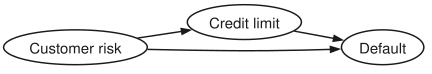

In [5]:
chh.draw_dag([("Customer risk", "Credit limit"), ("Customer risk", "Default"),
              ("Credit limit", "Default")])



## Matching, and Where It Runs Out

The obvious fix: gather customers who look the same on everything the bank knew, compare big limits with small inside each group, then average.

With one control taking two values, that is two groups and it works.

The bank lends on about ten variables. Almost every group ends up holding <b style="color:#73000A;">one customer</b>, so there is nothing to compare it with.

## Regression Does the Adjusting

Put the confounders in the model instead:

$$\text{default} = \beta_0 + \beta_1 \,\text{limit} + \boldsymbol{\theta}'X + \varepsilon$$

The coefficient on the limit turns <b style="color:#73000A;">positive</b>, about $+3.06 \times 10^{-6}$.

Same data. The sign flipped because we stopped comparing across risk levels.

## Frisch-Waugh-Lovell

One big regression gives $\hat\beta_1$. So do three small ones:

1. Regress the <b style="color:#73000A;">treatment</b> on the controls, keep the residual $\tilde{T}$
2. Regress the <b style="color:#73000A;">outcome</b> on the controls, keep the residual $\tilde{Y}$
3. Regress $\tilde{Y}$ on $\tilde{T}$

The slope from step 3 equals $\hat\beta_1$ from the full regression. Exactly, not approximately.

## Step 1, Debias

Regress the credit limit on wage and the credit scores, and keep the residual.

$\tilde{T}$ is still the credit limit, <b style="color:#73000A;">still in dollars</b>, with the part the bank's own rules could predict taken out.

What is left is variation in the limit that has nothing to do with $X$. That is the part that acts as if it were randomly assigned.

## Step 2, Denoise

After debiasing, $\tilde{Y}$ still carries variation that $X$ could have explained.

Taking $X$ out of the outcome does not change the estimate. It shrinks the <b style="color:#73000A;">standard error</b>.

$$SE = \frac{\hat\sigma}{\sqrt{\sum \tilde{T}_i^2}}$$

Smaller residuals on top, so a tighter interval. Skip step 2 and the estimate is still unbiased, just noisier.

## Regression Is Projection

The fitted values are the shadow of $\mathbf{y}$ on the plane spanned by the regressors. 

If the gap leaned even slightly along the plane, you could slide the fit and do better. So at the best fit it leans not at all.

A right angle means the residuals are <b style="color:#73000A;">uncorrelated with every variable in the model</b>.

## Shape and Confounding Are Different Problems

Spend against the credit limit bends, so take the square root and it straightens out.

That fixed the <b style="color:#73000A;">functional form</b>. It did nothing about the confounding.

Wage still drives both the limit and spend, and it still has to go in the model. Two problems, two separate fixes.

## Bad Controls

Adding controls is not free.

- Omit a confounder and you get <b style="color:#73000A;">bias</b>
- A <b style="color:#73000A;">neutral control</b> predicts the outcome but not the treatment. It helps precision
- A <b style="color:#73000A;">noise-inducing control</b> predicts the treatment but not the outcome. It soaks up the variation in $\tilde{T}$ and the estimate gets less precise

We can't throw the kitchen sink into the regression

### Question 1: The Bank

A bank regresses default on credit limit and nothing else. The slope comes out negative: customers with bigger credit lines default less.

What is that slope measuring?

- <b style="color:#73000A;">A.</b> The pure effect of credit on default
- <b style="color:#73000A;">B.</b> The bank's own lending policy, since it handed the biggest lines to the safest customers
- <b style="color:#73000A;">C.</b> Nothing, because default is 0 or 1 and the slope is tiny
- <b style="color:#73000A;">D.</b> The effect of credit, measured on too few customers to be sure

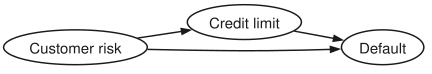

In [6]:
chh.draw_dag([("Customer risk", "Credit limit"), ("Customer risk", "Default"),
              ("Credit limit", "Default")])

### Question 2: Comparing Lookalikes

A potential correction is to gather customers who match on everything the bank knew, compare high limits with low inside each group, then average those comparisons.

The bank lends on about ten variables. Why can it not just do that?

- <b style="color:#73000A;">A.</b> Averaging comparisons only works when the treatment is yes or no
- <b style="color:#73000A;">B.</b> The comparison needs a model of default, and there is not one
- <b style="color:#73000A;">C.</b> Almost every group ends up holding one customer, and one customer has nobody to compare against
- <b style="color:#73000A;">D.</b> It would work, but the arithmetic takes too long to run

### Question 3

Spending rises with the credit limit, but the curve bends. You take the <b style="color:#73000A;">square root</b> of the limit and the relationship straightens out.

Wage drives both the limit and spending, and wage is not in the model.

What has the square root fixed?

- <b style="color:#73000A;">A.</b> Everything. A straight relationship is an unconfounded one
- <b style="color:#73000A;">B.</b> The shape only. The confounding is still there... wage still has to go into the model
- <b style="color:#73000A;">C.</b> The confounding only, since transforming the limit breaks its link to wage
- <b style="color:#73000A;">D.</b> Neither. A transformation cannot move an estimate

### Question 4: The Right Angle

Fit any regression and the leftovers meet the fitted surface at a right angle.

That right angle means:

- <b style="color:#73000A;">A.</b> The residuals are normally distributed
- <b style="color:#73000A;">B.</b> The residuals are uncorrelated with every variable in the model
- <b style="color:#73000A;">C.</b> The residuals have the same spread at every value of $X$
- <b style="color:#73000A;">D.</b> The residuals are uncorrelated with each other

### Question 5: A Residual You Keep

Most of the time a residual is whatever a model could not explain, and it is the part you set aside.

Here you regress the <b style="color:#73000A;">credit limit</b> on wage and the two scores, keep the residual $\tilde{T}$, and then use <i>that</i> as your regressor.

What is $\tilde{T}$?

- <b style="color:#73000A;">A.</b> The credit limit itself, still in dollars, with the part the bank's own rules could predict taken out
- <b style="color:#73000A;">B.</b> The part of default that the controls cannot explain
- <b style="color:#73000A;">C.</b> Noise, so any slope estimated from it is noise too
- <b style="color:#73000A;">D.</b> The bank's predicted credit limit

### Question 6: Debias and Denoise

To get the effect of credit limit holding wage fixed, you can run two small regressions and then a third:

1. Take wage out of the <b style="color:#73000A;">limit</b>, keep the leftover (residuals)
2. Take wage out of <b style="color:#73000A;">default</b>, keep the leftover
3. Regress leftover on leftover

Skip step 2. Regress raw default on the leftover limit. What changes?

- <b style="color:#73000A;">A.</b> Nothing at all
- <b style="color:#73000A;">B.</b> The estimate is confounded by wage again
- <b style="color:#73000A;">C.</b> The estimate is the same, but the standard error is bigger
- <b style="color:#73000A;">D.</b> The estimate changes, but the standard error does not

### Question 7: A Bad Control

One variable in your data predicts the treatment almost perfectly. It has nothing to do with the outcome except through the treatment.

You add it as a control. What happens?

- <b style="color:#73000A;">A.</b> Bias falls, so it earns its place
- <b style="color:#73000A;">B.</b> Nothing, since it never touches the outcome
- <b style="color:#73000A;">C.</b> It soaks up the treatment's variation, and the estimate gets much less precise
- <b style="color:#73000A;">D.</b> It opens a back door and biases the estimate

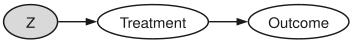

In [7]:
chh.draw_dag([("Z", "Treatment"), ("Treatment", "Outcome")], boxed=("Z",))